# QSAR Falcipaína-2 — MACCS


In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     StratifiedGroupKFold, GroupShuffleSplit,
                                     GridSearchCV, RepeatedStratifiedKFold,
                                     cross_validate)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors

OUTPUT_DIR_AD   = "resultados dominio de aplicabilidad maccs"
OUTPUT_DIR_ML   = "resultados modelos ML MACCS"
OUTPUT_DIR_INT  = "resultados interpretabilidad MACCS"
FIGURAS         = "figuras"

for _d in (OUTPUT_DIR_AD, OUTPUT_DIR_ML,OUTPUT_DIR_INT, FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE = 42


In [3]:
# =============================================================================
# 1. Carga de datos y LIMPIEZA DE DUPLICADOS DE FINGERPRINT
# =============================================================================
# Antes de dividir en train/test hay que resolver un problema encontrado en el
# dataset: 113 de 470 filas (24%) comparten un vector MACCS EXACTAMENTE IGUAL
# al de otra fila. Si esos duplicados caen uno en train y otro en test, el
# modelo simplemente "reconoce" el vector visto en entrenamiento -> AUC/ACC
# perfectos que no reflejan capacidad de generalización real.
#
# Además, 10 de esos 42 grupos de duplicados tienen ETIQUETAS CONTRADICTORIAS
# (mismo vector MACCS -> un compuesto activo y otro inactivo). Esos casos no
# son arreglables con más modelado: MACCS no tiene resolución suficiente para
# distinguirlos, así que se eliminan por ser ruido de las propias features.

df_final = pd.read_csv("MACCS_c+g_con_actividad.csv")

feat_cols_all = [c for c in df_final.columns if c.startswith("MACCS_")]

# 1a) Detectar grupos de vectores MACCS duplicados con etiqueta inconsistente
dup_mask = df_final.duplicated(subset=feat_cols_all, keep=False)
conflict_groups = (df_final[dup_mask]
                    .groupby(feat_cols_all)['Label_FP2']
                    .nunique())
conflict_keys = set(conflict_groups[conflict_groups > 1].index)

df_final['_dup_key'] = df_final[feat_cols_all].apply(tuple, axis=1)
n_before = len(df_final)
df_clean = df_final[~df_final['_dup_key'].isin(conflict_keys)].copy()
n_after_conflict = len(df_clean)

# 1b) Colapsar duplicados exactos restantes a un único representante
#     (mismo vector MACCS, misma etiqueta -> son redundantes para el modelo)
df_clean = df_clean.drop_duplicates(subset=feat_cols_all, keep='first').reset_index(drop=True)
n_final = len(df_clean)

print(f"Compuestos originales                          : {n_before}")
print(f"  - eliminados por etiqueta contradictoria       : {n_before - n_after_conflict}")
print(f"  - eliminados por ser duplicado exacto redundante: {n_after_conflict - n_final}")
print(f"Compuestos finales usados para modelar          : {n_final}")

df_final = df_clean.drop(columns=['_dup_key'])

X_full = df_final[feat_cols_all].astype(float)
y = df_final['Label_FP2'].astype(int)

feature_sets = {
    "maccs_full": X_full.columns.tolist()
}

print(f"\nDistribución de clases tras limpieza:")
print(y.value_counts())
print(f"  Activos: {y.mean():.1%}")


Compuestos originales                          : 470
  - eliminados por etiqueta contradictoria       : 25
  - eliminados por ser duplicado exacto redundante: 56
Compuestos finales usados para modelar          : 389

Distribución de clases tras limpieza:
Label_FP2
0    250
1    139
Name: count, dtype: int64
  Activos: 35.7%


In [4]:
# =============================================================================
# 2. Split train/test
# =============================================================================
# Como ya no quedan vectores MACCS exactamente duplicados en el dataset, un
# train_test_split estratificado normal ya no filtra información entre train
# y test por esa vía. Aun así usamos GroupShuffleSplit con un id de grupo
# basado en el propio vector MACCS: es una red de seguridad barata que
# garantiza que, si en el futuro añades más compuestos y vuelven a aparecer
# duplicados, seguirán cayendo enteros en un solo lado del split.

groups_all = X_full.apply(lambda r: hash(tuple(r)), axis=1)

# StratifiedGroupKFold en vez de GroupShuffleSplit: como cada compuesto es su
# propio grupo (tamano 1) tras la limpieza de duplicados, GroupShuffleSplit
# equivale a un split aleatorio SIN estratificar por clase, lo que puede
# descompensar train/test. StratifiedGroupKFold respeta los grupos Y mantiene
# la proporcion de clases (misma robustez que en el pipeline de Mordred).
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_full, y, groups=groups_all))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
X_test_full  = X_full.iloc[test_idx].reset_index(drop=True)
y_train      = y.iloc[train_idx].reset_index(drop=True)
y_test       = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups_all.iloc[train_idx].reset_index(drop=True)

# guardamos también los índices originales de df_final para el análisis de AD (paso 8)
train_orig_idx = df_final.index[train_idx]
test_orig_idx  = df_final.index[test_idx]

print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")


Train: 311 muestras | Test: 78 muestras
  Train activos: 108 (34.7%)
  Test  activos: 31 (39.7%)


In [5]:
# =============================================================================
# 3. Definición de modelos y rejillas de hiperparámetros
# =============================================================================
MODEL_DEFINITIONS = [
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "clf__max_depth"        : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"        : ["gini", "entropy"],
        }
    ),
    (
        "RandomForest",
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "clf__n_estimators"     : [100, 200, 300],
            "clf__max_depth"        : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"     : ["sqrt", "log2"],
        }
    ),
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "clf__n_estimators"     : [100, 200, 300],
            "clf__max_depth"        : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=RANDOM_STATE, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=RANDOM_STATE, max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),
    (
        "XGBoost",
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),
    (
        "LightGBM",
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]


In [6]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan

    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }


In [7]:
# =============================================================================
# 4. Entrenamiento: VarianceThreshold + CV por grupos + selección por CV
# =============================================================================

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results     = []
best_estimators = {}

n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos x "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")

for fs_name, feat_cols in feature_sets.items():
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]

    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  > {key}")

        # Pipeline: imputacion -> filtro de varianza -> escalado -> clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("varth",   VarianceThreshold(threshold=0.01)),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])

        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train, groups=groups_train)
        best_estimators[key] = gs.best_estimator_

        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]

        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} +/- {metrics['cv_roc_auc_std']:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")

# *** Criterio de selección: rendimiento en CV (train), NO en test ***
df_results = pd.DataFrame(all_results).sort_values("cv_roc_auc_mean", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso6_resultados_todos.csv', sep=";", index=False)
print(f"\nparaso6_resultados_todos.csv guardado.")



Entrenando 14 modelos x 1 feature sets = 14 experimentos...

  > LogisticRegression__maccs_full
      CV AUC=0.842 +/- 0.035 | Test AUC=0.889 | Gap=0.105
  > SVM_RBF__maccs_full
      CV AUC=0.847 +/- 0.024 | Test AUC=0.899 | Gap=0.064
  > SVM_Linear__maccs_full
      CV AUC=0.841 +/- 0.036 | Test AUC=0.869 | Gap=0.048
  > KNeighbors__maccs_full
      CV AUC=0.856 +/- 0.039 | Test AUC=0.887 | Gap=0.179
  > DecisionTree__maccs_full
      CV AUC=0.775 +/- 0.014 | Test AUC=0.705 | Gap=0.250
  > RandomForest__maccs_full
      CV AUC=0.863 +/- 0.019 | Test AUC=0.903 | Gap=0.147
  > ExtraTrees__maccs_full
      CV AUC=0.867 +/- 0.024 | Test AUC=0.895 | Gap=0.128
  > GradientBoosting__maccs_full
      CV AUC=0.855 +/- 0.022 | Test AUC=0.844 | Gap=0.256
  > AdaBoost__maccs_full
      CV AUC=0.832 +/- 0.034 | Test AUC=0.873 | Gap=0.051
  > MLP__maccs_full
      CV AUC=0.841 +/- 0.033 | Test AUC=0.861 | Gap=0.231
  > NaiveBayes__maccs_full
      CV AUC=0.772 +/- 0.054 | Test AUC=0.766 | Gap=0.0

In [8]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso7_resultados_rankeados.csv', sep=";", index=False)

top5 = df_results.head(3)

best_row = df_results.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "n_features", "cv_roc_auc_mean", "cv_roc_auc_std",
             "roc_auc_test", "overfit_gap","score_balanced"]
print("\nTOP 3 MEJORES MODELOS (seleccionados por CV, MACCS):")
print(top5[cols_show].to_string(index=False))



TOP 3 MEJORES MODELOS (seleccionados por CV, MACCS):
     model  n_features  cv_roc_auc_mean  cv_roc_auc_std  roc_auc_test  overfit_gap  score_balanced
   SVM_RBF         167         0.846554        0.024454      0.899108     0.063732        0.867242
  AdaBoost         167         0.831526        0.034471      0.873370     0.050787        0.847976
SVM_Linear         167         0.840674        0.036184      0.868909     0.047613        0.845102


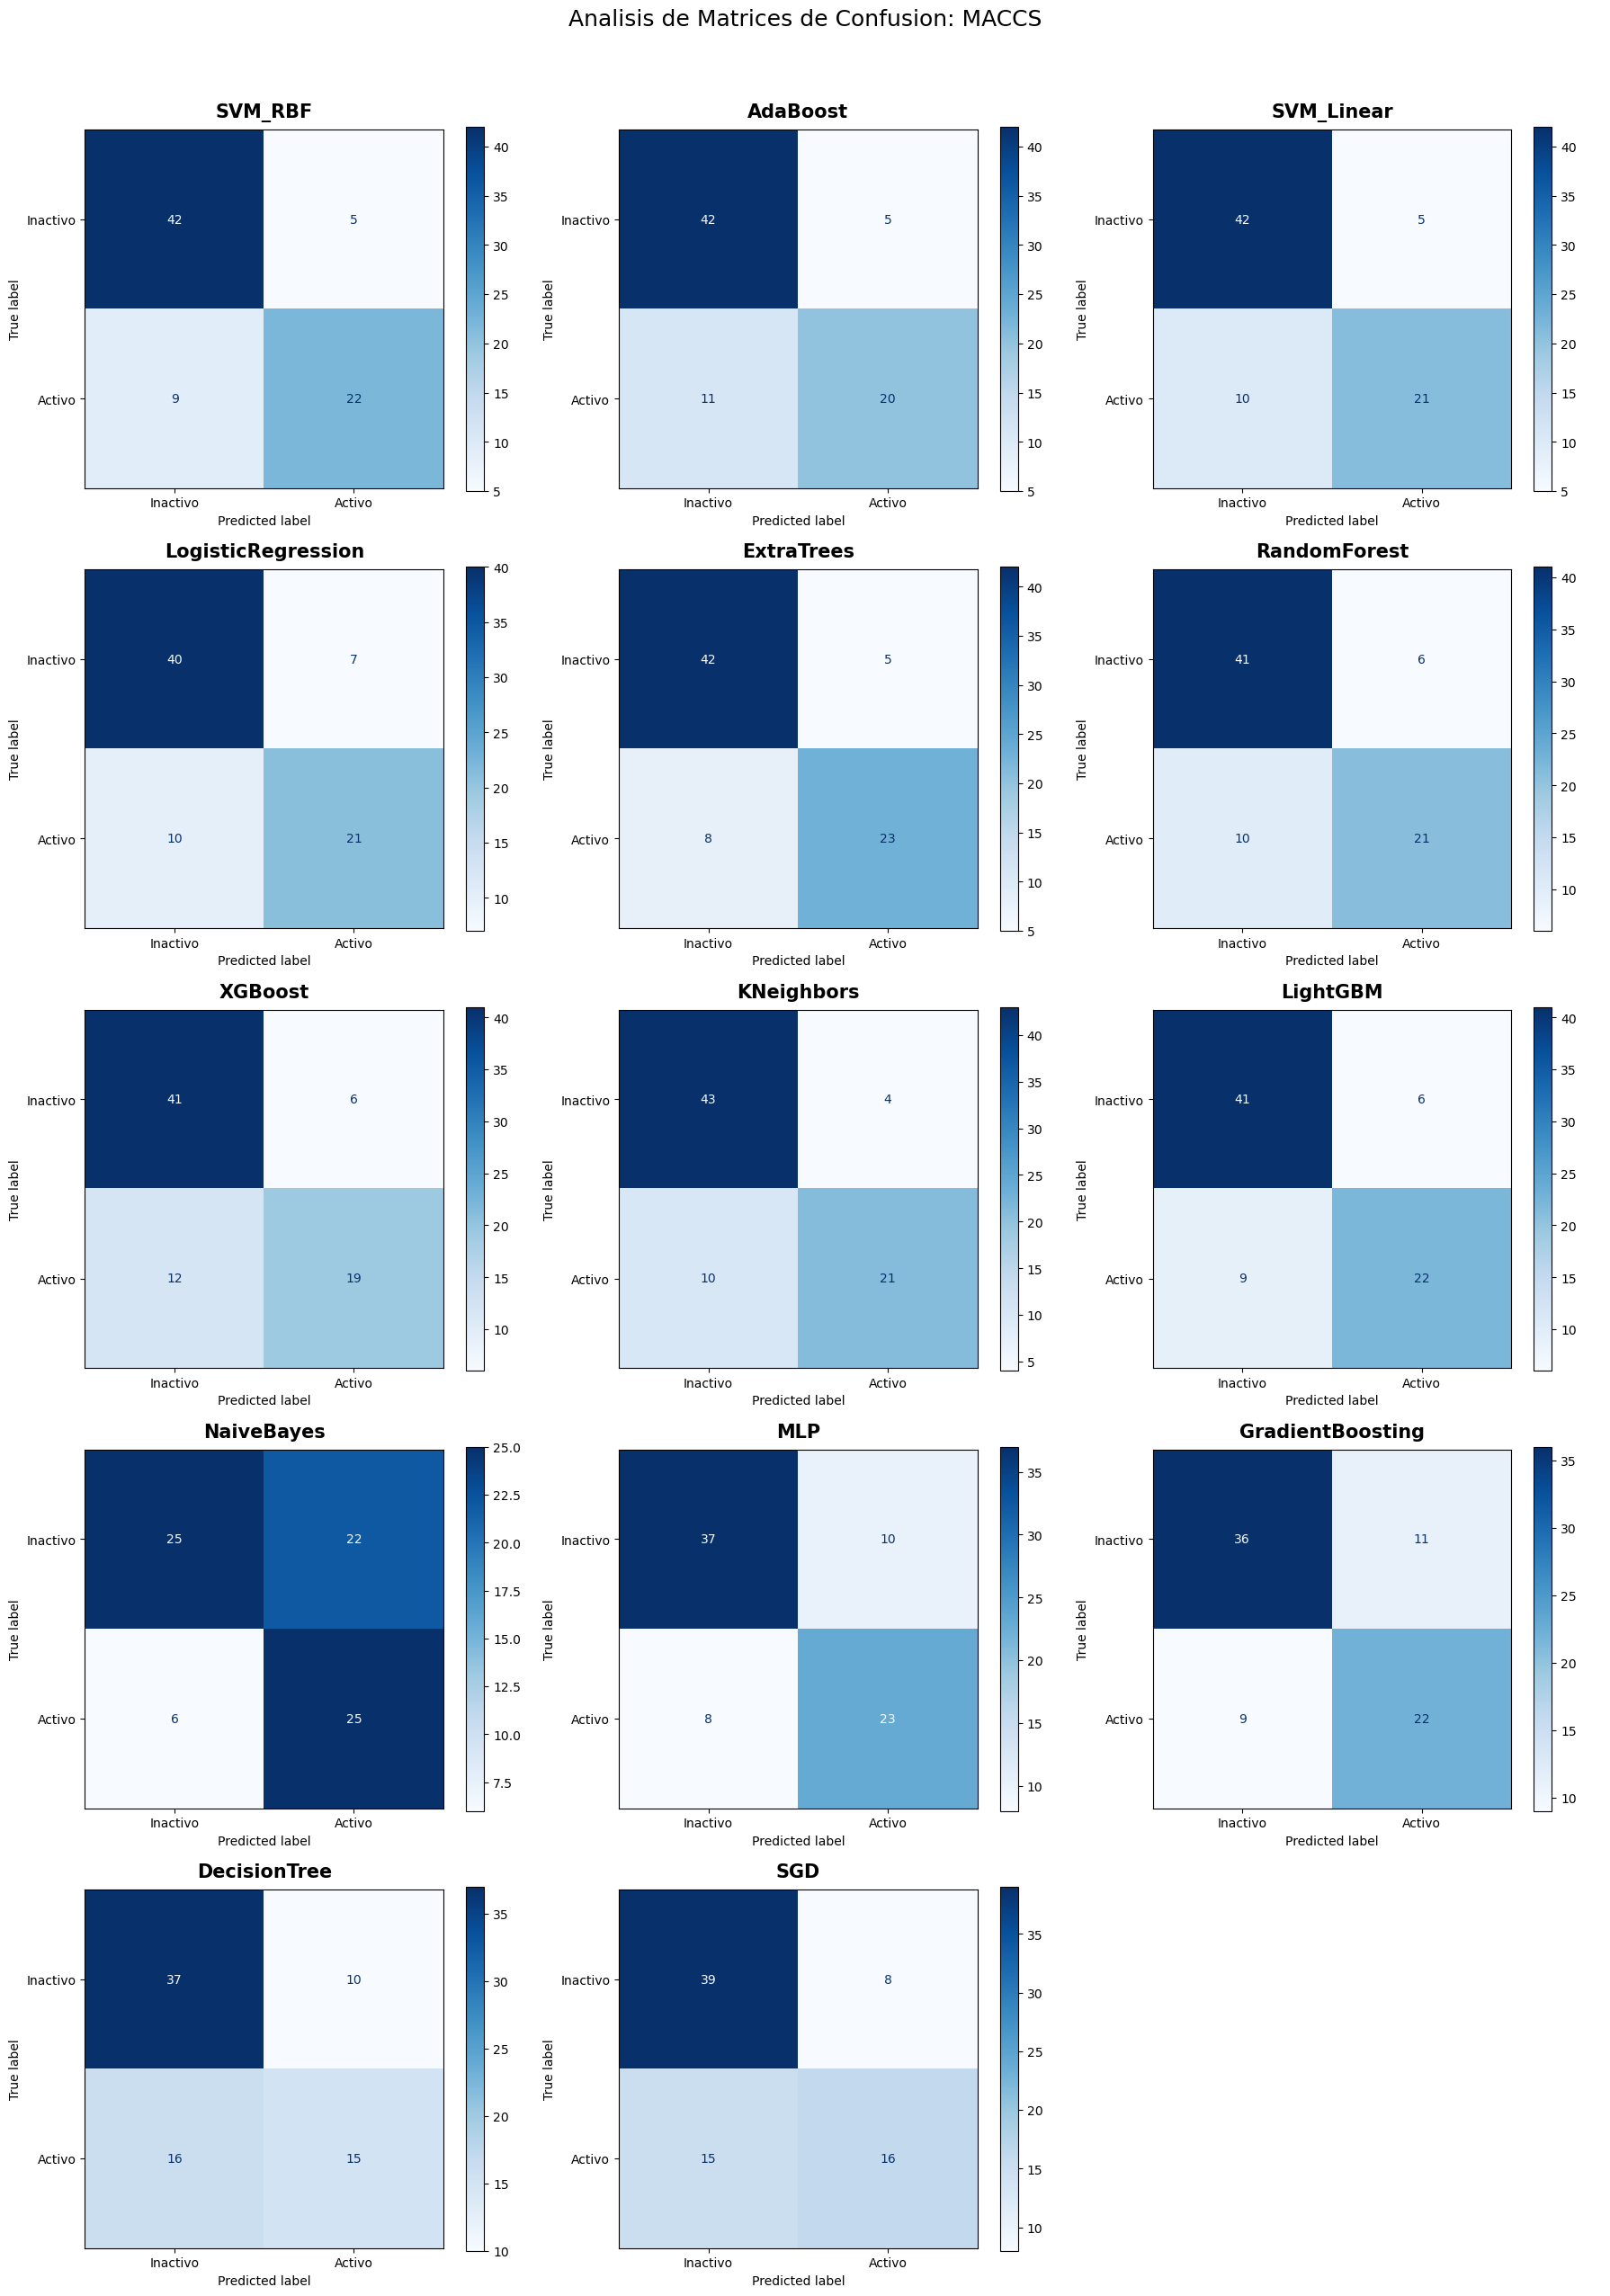

In [9]:
def plot_matrices_final(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    n_models = len(method_results)
    if n_models == 0: return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(method_results.iterrows()):
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactivo", "Activo"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=15, pad=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Analisis de Matrices de Confusion: {method_name.upper()}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURAS}/paso7_confusion_{method_name}_final_maccs.png', dpi=150, bbox_inches="tight")
    plt.show()

plot_matrices_final("maccs", df_results, best_estimators, feature_sets)


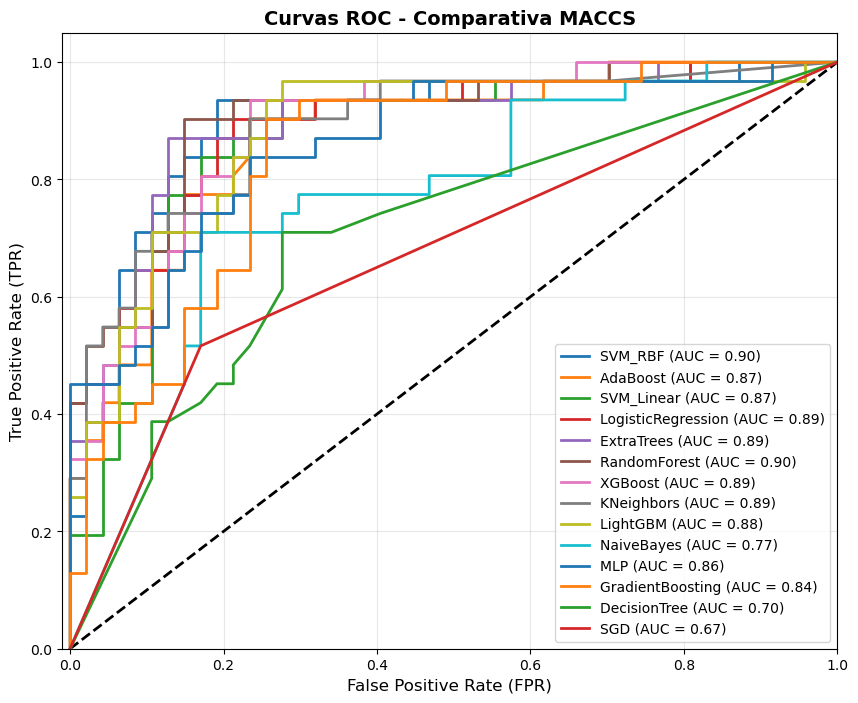

In [10]:
def plot_roc_curves_by_method(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    for _, row in method_results.iterrows():
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'Curvas ROC - Comparativa {method_name.upper()}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig(f'{FIGURAS}/paso7_roc_comparison_{method_name}_maccs.png', dpi=150, bbox_inches="tight")
    plt.show()

plot_roc_curves_by_method("Maccs", df_results, best_estimators, feature_sets)


In [11]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])

print(f"\n{'='*60}")
print(f"MEJOR MODELO (seleccionado por CV): {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"CV ROC-AUC   : {best_row['cv_roc_auc_mean']:.4f} +/- {best_row['cv_roc_auc_std']:.4f}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC (test) = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass

pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv(f'{OUTPUT_DIR_ML}/paso7_report_mejor_modelo_maccs.csv')

print(f"\nGraficos y reportes del paso 7 guardados.")



MEJOR MODELO (seleccionado por CV): SVM_RBF
Feature set  : maccs_full (167 descriptores)
CV ROC-AUC   : 0.8466 +/- 0.0245
              precision    recall  f1-score   support

    Inactivo       0.82      0.89      0.86        47
      Activo       0.81      0.71      0.76        31

    accuracy                           0.82        78
   macro avg       0.82      0.80      0.81        78
weighted avg       0.82      0.82      0.82        78

MCC = 0.6206
ROC-AUC (test) = 0.8991

Graficos y reportes del paso 7 guardados.


In [12]:
# =============================================================================
# 5. Estimación robusta de rendimiento (Repeated Stratified-Group K-Fold)
# =============================================================================
# Con ~380 compuestos de train, un único split 80/20 es muy sensible a qué
# compuestos caen en cada lado. Repetimos la validación muchas veces para
# obtener una media +/- desviación estándar en vez de un solo número.

from sklearn.model_selection import StratifiedGroupKFold as _SGKF

n_repeats = 10
aucs, mccs = [], []

for rep in range(n_repeats):
    cv_rep = _SGKF(n_splits=5, shuffle=True, random_state=rep)
    for tr_i, te_i in cv_rep.split(X_full, y, groups=groups_all):
        pipe_rep = clone(best_est)
        pipe_rep.fit(X_full.iloc[tr_i], y.iloc[tr_i])
        prob = pipe_rep.predict_proba(X_full.iloc[te_i])[:, 1]
        pred = pipe_rep.predict(X_full.iloc[te_i])
        if len(np.unique(y.iloc[te_i])) > 1:
            aucs.append(roc_auc_score(y.iloc[te_i], prob))
        mccs.append(matthews_corrcoef(y.iloc[te_i], pred))

print(f"ROC-AUC  (repeated group-CV, {n_repeats}x5-fold): "
      f"{np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")
print(f"MCC      (repeated group-CV, {n_repeats}x5-fold): "
      f"{np.mean(mccs):.3f} +/- {np.std(mccs):.3f}")



ROC-AUC  (repeated group-CV, 10x5-fold): 0.852 +/- 0.056
MCC      (repeated group-CV, 10x5-fold): 0.566 +/- 0.096


AUC real del modelo (test)     : 0.899
AUC con y-scrambling (20 veces) : 0.460 +/- 0.082
Si el AUC scrambled se acerca a 0.5, el modelo real está aprendiendo señal genuina y no ruido/artefactos.


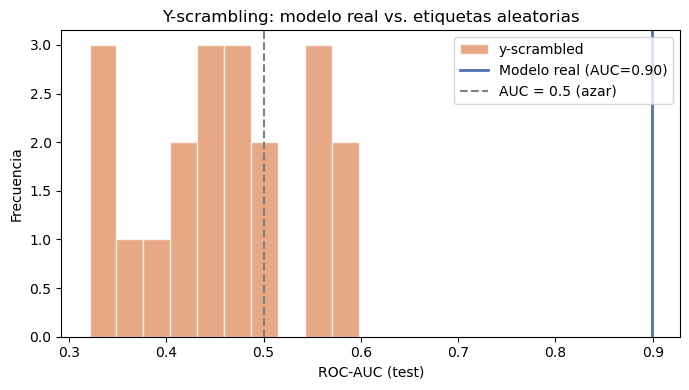

In [13]:
# =============================================================================
# 6. Control de y-scrambling
# =============================================================================
# Si el modelo obtiene buen AUC incluso con las etiquetas barajadas
# aleatoriamente, es señal de que está aprendiendo estructura espuria del
# dataset (p.ej. artefactos del split o de las features) y no una relación
# estructura-actividad real. Con etiquetas al azar el AUC esperado es ~0.5.

n_scrambles = 20
scrambled_aucs = []

rng = np.random.RandomState(RANDOM_STATE)
for i in range(n_scrambles):
    y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)
    m = clone(best_est)
    m.fit(X_train_full[best_fs], y_shuffled)
    p = m.predict_proba(X_test_full[best_fs])[:, 1]
    scrambled_aucs.append(roc_auc_score(y_test, p))

print(f"AUC real del modelo (test)     : {roc_auc_score(y_test, y_prob):.3f}")
print(f"AUC con y-scrambling ({n_scrambles} veces) : "
      f"{np.mean(scrambled_aucs):.3f} +/- {np.std(scrambled_aucs):.3f}")
print("Si el AUC scrambled se acerca a 0.5, el modelo real está aprendiendo "
      "señal genuina y no ruido/artefactos.")

plt.figure(figsize=(7, 4))
plt.hist(scrambled_aucs, bins=10, color='#DD8452', alpha=0.7, edgecolor='white',
         label='y-scrambled')
plt.axvline(roc_auc_score(y_test, y_prob), color='#4C72B0', linewidth=2,
            label=f"Modelo real (AUC={roc_auc_score(y_test, y_prob):.2f})")
plt.axvline(0.5, color='gray', linestyle='--', label='AUC = 0.5 (azar)')
plt.xlabel('ROC-AUC (test)')
plt.ylabel('Frecuencia')
plt.title('Y-scrambling: modelo real vs. etiquetas aleatorias')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIGURAS}/paso7b_yscrambling_{best_row["model"]}_maccs.png', dpi=150, bbox_inches='tight')
plt.show()


TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)
     model feature_set  n_features  cv_roc_auc_mean  roc_auc_test
   SVM_RBF  maccs_full         167         0.846554      0.899108
  AdaBoost  maccs_full         167         0.831526      0.873370
SVM_Linear  maccs_full         167         0.840674      0.868909

Descriptores (k)         : 167
Compuestos train (n)     : 311
Umbral kNN-AD            : 13.5531

Train - dist. media (mean +/- std): 8.1065 +/- 2.7233
Test  - dentro del AD    : 78 (100.0%)
Test  - fuera del AD     : 0 (0.0%)


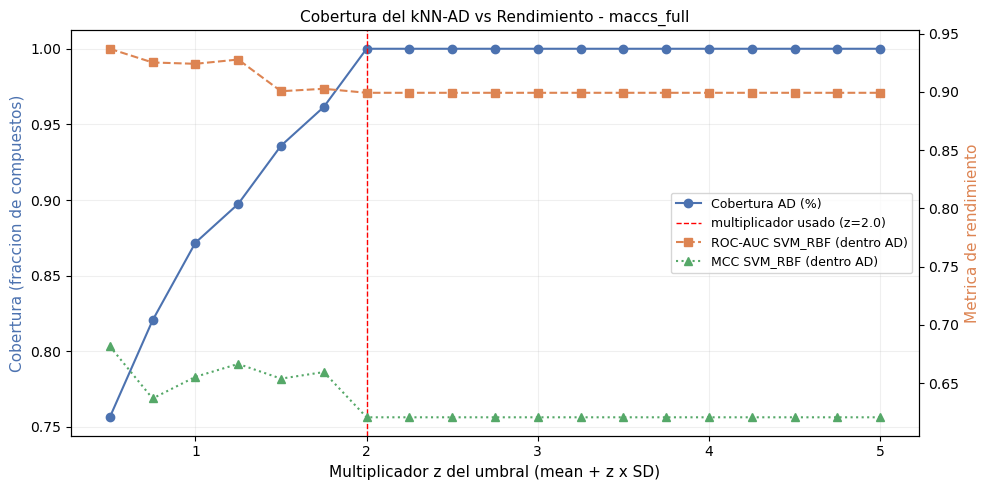

resultados dominio de aplicabilidad maccs/paso8_ad_coverage_maccs_full_maccs.png guardado.
split  in_AD
test   1         78
train  1        311
resultados dominio de aplicabilidad maccs/paso8_knnAD_maccs_full_maccs.csv guardado.

[1/3] MODELO: SVM_RBF  |  Feature set: maccs_full


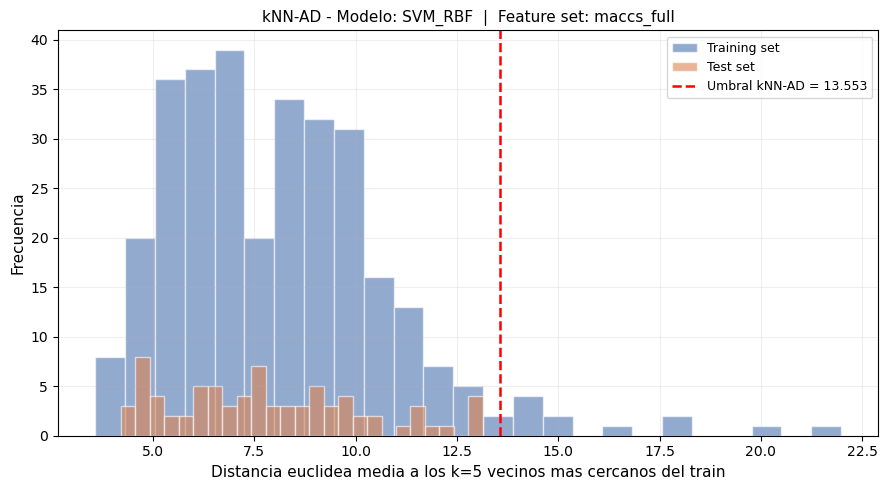

resultados dominio de aplicabilidad maccs/paso8_knnAD_hist_top1_SVM_RBF_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.8205
  F1        : 0.7586
  MCC       : 0.6206
  ROC-AUC   : 0.8991

-- Test dentro del AD (n=78) --
  Accuracy  : 0.8205
  F1        : 0.7586
  MCC       : 0.6206
  ROC-AUC   : 0.8991

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top1_SVM_RBF_maccs.csv guardado.

[2/3] MODELO: AdaBoost  |  Feature set: maccs_full


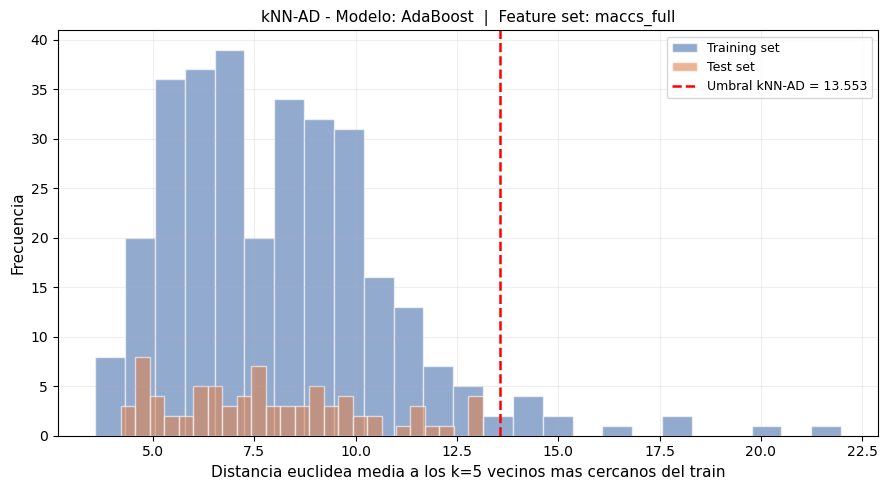

resultados dominio de aplicabilidad maccs/paso8_knnAD_hist_top2_AdaBoost_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.7949
  F1        : 0.7143
  MCC       : 0.5650
  ROC-AUC   : 0.8734

-- Test dentro del AD (n=78) --
  Accuracy  : 0.7949
  F1        : 0.7143
  MCC       : 0.5650
  ROC-AUC   : 0.8734

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top2_AdaBoost_maccs.csv guardado.

[3/3] MODELO: SVM_Linear  |  Feature set: maccs_full


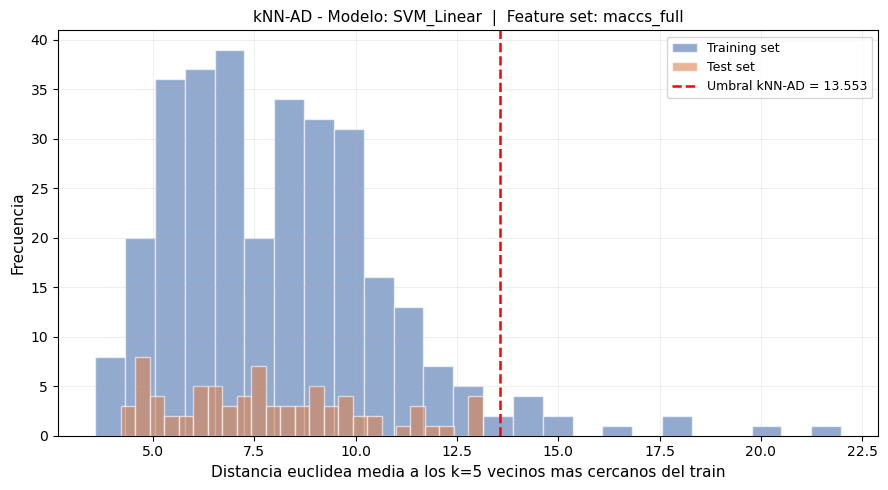

resultados dominio de aplicabilidad maccs/paso8_knnAD_hist_top3_SVM_Linear_maccs.png guardado.

-- Test completo (n=78) --
  Accuracy  : 0.8077
  F1        : 0.7368
  MCC       : 0.5928
  ROC-AUC   : 0.8689

-- Test dentro del AD (n=78) --
  Accuracy  : 0.8077
  F1        : 0.7368
  MCC       : 0.5928
  ROC-AUC   : 0.8689

-- Test fuera del AD (n=0) --
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad maccs/paso8_ad_metrics_top3_SVM_Linear_maccs.csv guardado.

RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)
 rank      model feature_set  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1    SVM_RBF  maccs_full       0.8991         0.8991   0.6206     0.6206
    2   AdaBoost  maccs_full       0.8734         0.8734   0.5650     0.5650
    3 SVM_Linear  maccs_full       0.8689         0.8689   0.5928     0.5928

paraso8_summary_top3_maccs.csv guardado.


In [14]:
# =============================================================================
# 7. Dominio de aplicabilidad - kNN-AD (TOP 3 modelos)
# =============================================================================
# Una molecula se considera DENTRO del dominio si esta "cerca" (en el espacio
# de descriptores estandarizado) de las moleculas del training set. Este
# metodo es agnostico al algoritmo de ML: depende solo del feature set, no
# del clasificador.
#
# Algoritmo (kNN-AD):
#   1. Estandarizar los descriptores con la media/SD del TRAIN set.
#   2. Para cada compuesto de train, calcular la distancia euclidea media a
#      sus k=5 vecinos mas cercanos DENTRO DEL PROPIO TRAIN (excluyendo el
#      compuesto consigo mismo, para no inflar artificialmente la distancia
#      media con un cero).
#   3. Umbral = media + 2 x desviacion estandar de esas distancias en train.
#   4. Para cada compuesto de test, calcular su distancia media a los k=5
#      vecinos mas cercanos DEL TRAIN. Si esa distancia < umbral, esta
#      dentro del AD.

def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n-- {label} (n={len(y_true)}) --")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def knn_ad(X_train: pd.DataFrame, X_test: pd.DataFrame, n_neighbors: int = 5, z: float = 2.0):
    scaler_ad = StandardScaler()
    X_train_ad = scaler_ad.fit_transform(X_train)
    X_test_ad  = scaler_ad.transform(X_test)

    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 porque el propio punto sera su vecino 0 en train
    nn.fit(X_train_ad)

    # Distancias en TRAIN: se excluye la columna 0 (distancia a si mismo = 0)
    distances_train, _ = nn.kneighbors(X_train_ad)
    mean_dist_train = distances_train[:, 1:].mean(axis=1)

    threshold = mean_dist_train.mean() + z * mean_dist_train.std()

    # Distancias en TEST: aqui SI se usan los n_neighbors mas cercanos del
    # train tal cual (el punto de test no esta en el training set, no hay
    # auto-match que excluir). Se reutiliza el mismo objeto nn (ya ajustado
    # con n_neighbors+1) y se descarta la ultima columna para mantener k=5.
    distances_test, _ = nn.kneighbors(X_test_ad)
    mean_dist_test = distances_test[:, :n_neighbors].mean(axis=1)

    return mean_dist_train, mean_dist_test, threshold, scaler_ad, nn


def plot_ad_distance_hist(model_name, mean_dist_train, mean_dist_test, threshold, fs_name, model_tag):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(mean_dist_train, bins=25, color="#4C72B0", alpha=0.6, edgecolor="white", label="Training set")
    ax.hist(mean_dist_test, bins=25, color="#DD8452", alpha=0.6, edgecolor="white", label="Test set")
    ax.axvline(threshold, color="red", linestyle="--", linewidth=1.8, label=f"Umbral kNN-AD = {threshold:.3f}")
    ax.set_xlabel("Distancia euclidea media a los k=5 vecinos mas cercanos del train", fontsize=11)
    ax.set_ylabel("Frecuencia", fontsize=11)
    ax.set_title(f"kNN-AD - Modelo: {model_name}  |  Feature set: {fs_name}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    out_hist = f'{OUTPUT_DIR_AD}/paso8_knnAD_hist_{model_tag}_maccs.png'
    plt.savefig(out_hist, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_hist} guardado.')


top3 = df_results.head(3).reset_index(drop=True)

print("=" * 60)
print("TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)")
print("=" * 60)
cols_show = ["model", "feature_set", "n_features", "cv_roc_auc_mean", "roc_auc_test"]
print(top3[cols_show].to_string(index=False))
print()

fs_name = top3.iloc[0]["feature_set"]   # "maccs_full" (unico feature set en MACCS)
fs_cols = feature_sets[fs_name]
best_key = f"{top3.iloc[0]['model']}__{fs_name}"

# ── kNN-AD: se calcula UNA vez (unico feature set, agnostico al modelo) ─────
mean_dist_train, mean_dist_test, threshold, scaler_ad, nn_ad = knn_ad(
    X_train_full[fs_cols], X_test_full[fs_cols], n_neighbors=5, z=2.0
)

print(f"Descriptores (k)         : {len(fs_cols)}")
print(f"Compuestos train (n)     : {len(X_train_full)}")
print(f"Umbral kNN-AD            : {threshold:.4f}")

mask_ad = mean_dist_test < threshold
print()
print(f"Train - dist. media (mean +/- std): {mean_dist_train.mean():.4f} +/- {mean_dist_train.std():.4f}")
print(f"Test  - dentro del AD    : {mask_ad.sum()} ({mask_ad.mean():.1%})")
print(f"Test  - fuera del AD     : {(~mask_ad).sum()} ({(~mask_ad).mean():.1%})")

# ── Cobertura del AD vs rendimiento del top1, variando el multiplicador z ───
z_values = np.arange(0.5, 5.1, 0.25)
top1_est = best_estimators[best_key]
y_pred_top1 = top1_est.predict(X_test_full[fs_cols])
y_prob_top1 = (top1_est.predict_proba(X_test_full[fs_cols])[:, 1]
               if hasattr(top1_est, "predict_proba")
               else top1_est.decision_function(X_test_full[fs_cols]))

coverages, aucs_cov, mccs_cov = [], [], []
for zval in z_values:
    thr = mean_dist_train.mean() + zval * mean_dist_train.std()
    mask = mean_dist_test < thr
    coverages.append(mask.mean())
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        aucs_cov.append(roc_auc_score(y_test[mask], y_prob_top1[mask]))
        mccs_cov.append(matthews_corrcoef(y_test[mask], y_pred_top1[mask]))
    else:
        aucs_cov.append(np.nan)
        mccs_cov.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(z_values, coverages, 'o-',  color='#4C72B0', label='Cobertura AD (%)')
ax2.plot(z_values, aucs_cov,  's--', color='#DD8452', label=f'ROC-AUC {top3.iloc[0]["model"]} (dentro AD)')
ax2.plot(z_values, mccs_cov,  '^:',  color='#55A868', label=f'MCC {top3.iloc[0]["model"]} (dentro AD)')
ax1.axvline(2.0, color='red', linestyle='--', linewidth=1, label='multiplicador usado (z=2.0)')
ax1.set_xlabel('Multiplicador z del umbral (mean + z x SD)', fontsize=11)
ax1.set_ylabel('Cobertura (fraccion de compuestos)', fontsize=11, color='#4C72B0')
ax2.set_ylabel('Metrica de rendimiento', fontsize=11, color='#DD8452')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.set_title(f'Cobertura del kNN-AD vs Rendimiento - {fs_name}', fontsize=11)
ax1.grid(alpha=0.2)
plt.tight_layout()
out_cov = f'{OUTPUT_DIR_AD}/paso8_ad_coverage_{fs_name}_maccs.png'
plt.savefig(out_cov, dpi=150, bbox_inches='tight')
plt.show()
print(f'{out_cov} guardado.')

# ── Guardar distancia media por compuesto (train + test) ────────────────────
df_ad_train = pd.DataFrame({
    'smiles_std'      : df_final.loc[train_orig_idx, 'smiles_std'].values,
    'split'           : 'train',
    'mean_dist_5nn'   : mean_dist_train,
    'label'           : y_train.values,
    'in_AD'           : 1,  # por definicion, el training set siempre esta dentro de su propio dominio
    'feature_set'     : fs_name,
})
df_ad_test = pd.DataFrame({
    'smiles_std'      : df_final.loc[test_orig_idx, 'smiles_std'].values,
    'split'           : 'test',
    'mean_dist_5nn'   : mean_dist_test,
    'label'           : y_test.values,
    'in_AD'           : mask_ad.astype(int),
    'feature_set'     : fs_name,
})
df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
out_dist = f'{OUTPUT_DIR_AD}/paso8_knnAD_{fs_name}_maccs.csv'
df_ad_all.to_csv(out_dist, index=False)
print(df_ad_all.groupby(['split', 'in_AD']).size().rename('n_compuestos').to_string())
print(f'{out_dist} guardado.')

# =============================================================================
# Histograma + rendimiento dentro / fuera del AD, POR CADA UNO de los 3 modelos
# =============================================================================
summary_rows = []
for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]
    model_tag  = f"top{rank}_{model_name}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO: {model_name}  |  Feature set: {fs_name}")
    print("=" * 60)

    # Histograma de distancias individual para este modelo (mismo criterio
    # kNN-AD, pero figura propia identificada con el nombre del modelo)
    plot_ad_distance_hist(model_name, mean_dist_train, mean_dist_test, threshold, fs_name, model_tag)

    y_pred_test = est.predict(X_test_full[fs_cols])
    y_prob_test = (est.predict_proba(X_test_full[fs_cols])[:, 1]
                   if hasattr(est, "predict_proba")
                   else est.decision_function(X_test_full[fs_cols]))

    r_all = metrics_summary(y_test, y_pred_test, y_prob_test, 'Test completo')
    r_ad  = metrics_summary(y_test[mask_ad], y_pred_test[mask_ad], y_prob_test[mask_ad], 'Test dentro del AD')
    r_out = metrics_summary(y_test[~mask_ad], y_pred_test[~mask_ad], y_prob_test[~mask_ad], 'Test fuera del AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = model_name
    df_ad_metrics['feature_set'] = fs_name
    out_metrics = f'{OUTPUT_DIR_AD}/paso8_ad_metrics_{model_tag}_maccs.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"{out_metrics} guardado.")

    summary_rows.append({
        'rank'          : rank,
        'model'         : model_name,
        'feature_set'   : fs_name,
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(r_ad['roc_auc'], 4) if not np.isnan(r_ad['roc_auc']) else np.nan,
        'mcc_all'       : round(r_all['mcc'], 4),
        'mcc_in_AD'     : round(r_ad['mcc'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR_AD}/paso8_summary_top3_maccs.csv', index=False)
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)")
print("=" * 60)
print(df_summary.to_string(index=False))
print('\nparaso8_summary_top3_maccs.csv guardado.')



[1/3] Permutation importance: SVM_RBF | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
  MACCS_23         0.012583        0.007448 negativo (-)
 MACCS_111         0.007207        0.005018 negativo (-)
 MACCS_134         0.006818        0.006072 negativo (-)
 MACCS_151         0.006246        0.007129 positivo (+)
 MACCS_132         0.006200        0.004609 negativo (-)
  MACCS_93         0.005971        0.005721 positivo (+)
  MACCS_91         0.005971        0.004505 negativo (-)
  MACCS_97         0.005788        0.006102 negativo (-)
 MACCS_153         0.005193        0.005836 negativo (-)
 MACCS_155         0.005170        0.002932 positivo (+)
  MACCS_32         0.005148        0.003159 positivo (+)
  MACCS_33         0.005148        0.003159 positivo (+)
  MACCS_43         0.004896        0.003539 positivo (+)
  MACCS_64         0.004621        0.004029 positivo (+)
 MACCS_103         0.004507    

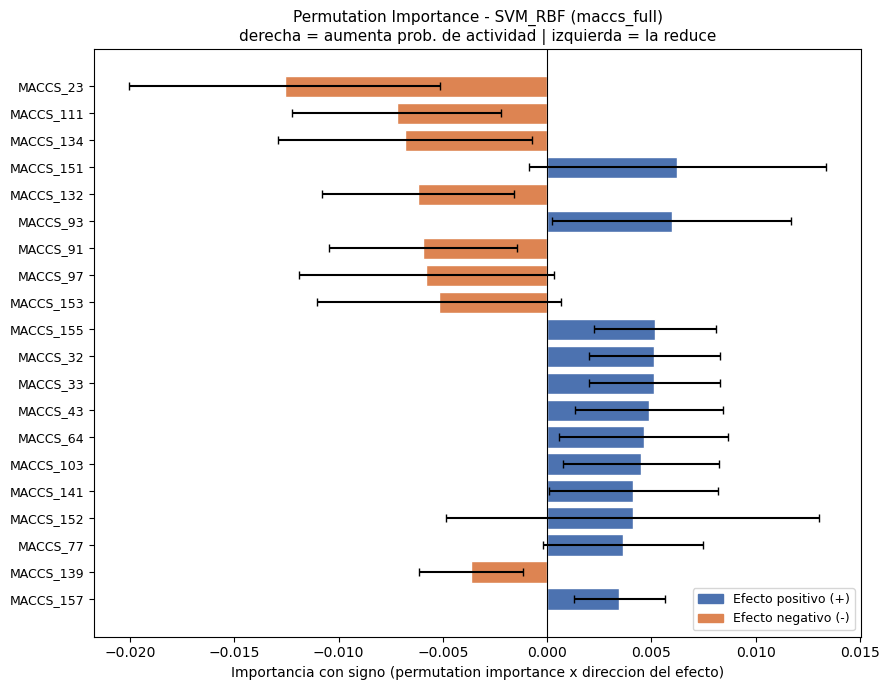

figuras/paso9_permutation_importance_top1_SVM_RBF_maccs.png guardado.

[2/3] Permutation importance: AdaBoost | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
 MACCS_153         0.045859        0.017520 negativo (-)
  MACCS_23         0.041421        0.015657 negativo (-)
  MACCS_97         0.028071        0.015151 negativo (-)
 MACCS_152         0.023908        0.014170 positivo (+)
 MACCS_151         0.019092        0.016120 positivo (+)
  MACCS_34         0.012960        0.010184 positivo (+)
  MACCS_13         0.011199        0.012636 positivo (+)
  MACCS_91         0.009094        0.004015 negativo (-)
 MACCS_132         0.008797        0.003589 negativo (-)
 MACCS_115         0.008602        0.016875 positivo (+)
 MACCS_103         0.008099        0.002936 negativo (-)
  MACCS_64         0.006566        0.004564 positivo (+)
 MACCS_109         0.006040        0.003598 positivo (+)
  MACCS_86       

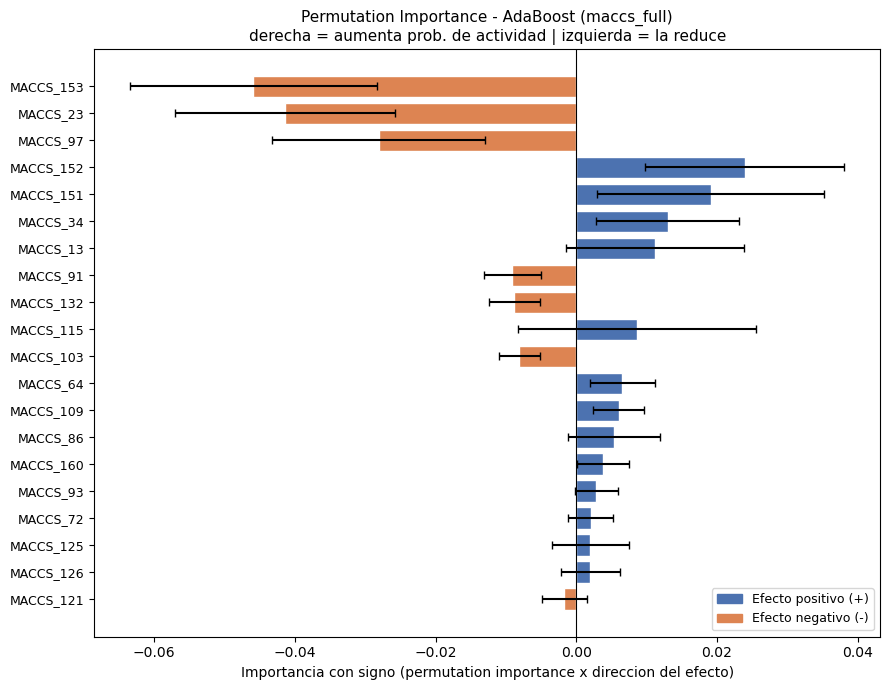

figuras/paso9_permutation_importance_top2_AdaBoost_maccs.png guardado.

[3/3] Permutation importance: SVM_Linear | maccs_full (167 bits MACCS)
Top 20 bits MACCS por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
  MACCS_23         0.017868        0.010764 negativo (-)
  MACCS_97         0.015443        0.006893 negativo (-)
 MACCS_153         0.012766        0.009185 negativo (-)
 MACCS_111         0.011691        0.007438 negativo (-)
 MACCS_151         0.011233        0.008847 positivo (+)
  MACCS_34         0.010890        0.006038 positivo (+)
  MACCS_43         0.009403        0.003540 positivo (+)
 MACCS_135         0.008602        0.005235 negativo (-)
 MACCS_134         0.007962        0.005289 negativo (-)
 MACCS_155         0.006154        0.003172 positivo (+)
  MACCS_91         0.006131        0.005381 negativo (-)
  MACCS_93         0.005994        0.005704 positivo (+)
  MACCS_13         0.005925        0.007050 positivo (+)
 MACCS_103    

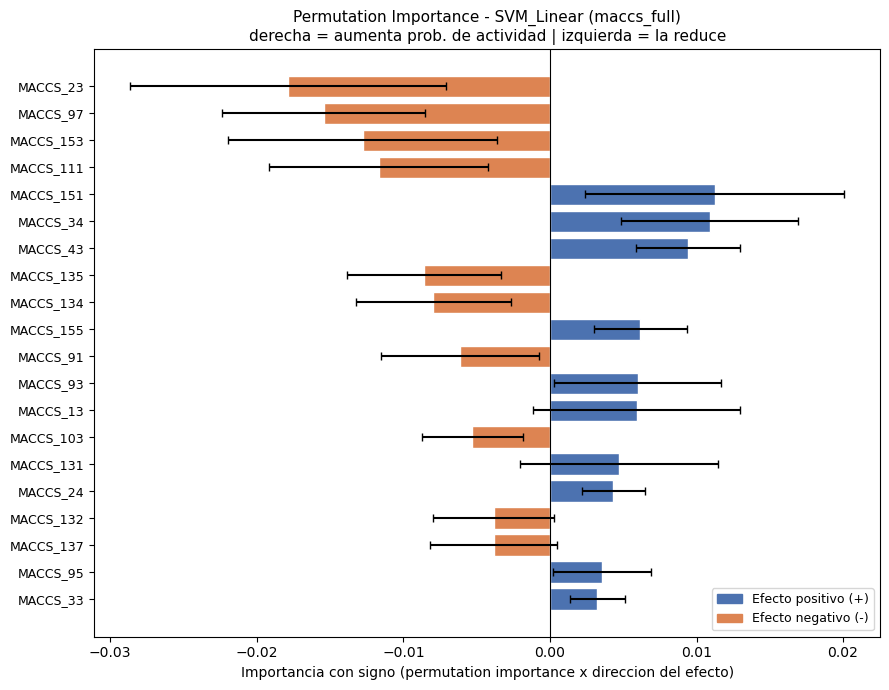

figuras/paso9_permutation_importance_top3_SVM_Linear_maccs.png guardado.

paraso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos.


In [15]:
# =============================================================================
# 8. Interpretabilidad: Permutation Feature Importance (TOP 3 modelos)
# =============================================================================
# La importancia por permutacion mide cuanto empeora el rendimiento del
# modelo (ROC-AUC) al barajar aleatoriamente los valores de un bit MACCS,
# rompiendo su relacion con la actividad. Se calcula sobre el TEST SET (no
# sobre train), para que refleje la contribucion real del bit a la capacidad
# de generalizacion, no a su ajuste a los datos de entrenamiento.
#
# La importancia por permutacion solo mide MAGNITUD (cuanto importa), no
# DIRECCION (si el bit favorece o penaliza la actividad). Para estimar la
# direccion se calcula la correlacion de Pearson entre el valor del bit (0/1)
# y la probabilidad predicha por el propio modelo en el test set: correlacion
# positiva -> la presencia de ese fragmento estructural aumenta la
# probabilidad de actividad; negativa -> la reduce. Es una aproximacion (no
# capta relaciones no monotonas), pero es el criterio habitual en QSAR cuando
# se usan modelos no lineales que no tienen coeficientes directos.
#
# En el grafico, la barra se dibuja hacia la DERECHA si el bit MACCS tiene
# efecto positivo sobre la actividad y hacia la IZQUIERDA si tiene efecto
# negativo (importancia con signo = importancia * signo de la correlacion).
#
# Se reutilizan los mismos TOP 3 modelos (top3) y el mismo feature set
# (fs_name / fs_cols) ya seleccionados en la seccion de Dominio de Aplicabilidad.

N_TOP_DESCRIPTORS = 20
N_REPEATS_PI       = 30

def permutation_importance_report(model_name, est, fs_name, feat_cols, X_te, y_te,
                                   n_repeats=N_REPEATS_PI, random_state=42):
    result = permutation_importance(
        est, X_te[feat_cols], y_te,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_te[feat_cols])[:, 1]
    else:
        y_prob = est.decision_function(X_te[feat_cols])

    directions = []
    for col in feat_cols:
        col_vals = X_te[col].values
        if np.std(col_vals) == 0:
            directions.append(0.0)
        else:
            r, _ = pearsonr(col_vals, y_prob)
            directions.append(r)

    imp_df = pd.DataFrame({
        "descriptor"     : feat_cols,
        "importance_mean": result.importances_mean,
        "importance_std" : result.importances_std,
        "direction_corr" : directions,
    })
    imp_df["sign"] = np.where(imp_df["direction_corr"] >= 0, 1, -1)
    imp_df["signed_importance"] = imp_df["importance_mean"] * imp_df["sign"]
    imp_df["effect"] = np.where(imp_df["direction_corr"] >= 0, "positivo (+)", "negativo (-)")
    imp_df = imp_df.reindex(
        imp_df["importance_mean"].sort_values(ascending=False).index
    ).reset_index(drop=True)
    imp_df.insert(0, "model", model_name)
    imp_df.insert(1, "feature_set", fs_name)
    return imp_df


all_importance_dfs = []

for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]

    print("\n" + "=" * 60)
    print(f"[{rank}/3] Permutation importance: {model_name} | {fs_name} ({len(fs_cols)} bits MACCS)")
    print("=" * 60)

    imp_df = permutation_importance_report(model_name, est, fs_name, fs_cols, X_test_full, y_test)
    all_importance_dfs.append(imp_df)

    top_n = imp_df.head(N_TOP_DESCRIPTORS)
    out_csv = f'{OUTPUT_DIR_INT}/paso9_permutation_importance_top{rank}_{model_name}.csv'
    imp_df.to_csv(out_csv, index=False)
    print(f"Top {N_TOP_DESCRIPTORS} bits MACCS por importancia (ROC-AUC):")
    print(top_n[["descriptor", "importance_mean", "importance_std", "effect"]].to_string(index=False))
    print(f"{out_csv} guardado.")

    # Orden visual: de mayor a menor importancia absoluta, de arriba a abajo
    top_n_plot = top_n.iloc[::-1]
    colors = np.where(top_n_plot["sign"] > 0, "#4C72B0", "#DD8452")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_n_plot))))
    y_pos = np.arange(len(top_n_plot))
    ax.barh(y_pos, top_n_plot["signed_importance"],
            xerr=top_n_plot["importance_std"],
            color=colors, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n_plot["descriptor"], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Importancia con signo (permutation importance x direccion del efecto)")
    ax.set_title(f"Permutation Importance - {model_name} ({fs_name})\n"
                 f"derecha = aumenta prob. de actividad | izquierda = la reduce", fontsize=11)
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="Efecto positivo (+)"),
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="Efecto negativo (-)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
    plt.tight_layout()
    out_png = f'{FIGURAS}/paso9_permutation_importance_top{rank}_{model_name}_maccs.png'
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_png} guardado.")

df_importance_all = pd.concat(all_importance_dfs, ignore_index=True)
df_importance_all.to_csv(f'{OUTPUT_DIR_INT}/paso9_permutation_importance_all.csv', index=False)
print(f"\nparaso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos.")
